In [1]:
# Setup PyCUDA (Colab / Linux)
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 36.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.1 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=63ceb91fd6c23cfdb207a23192a57b23acbde758f550219074651c23ec30abe4
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [2]:
#Cek GPU
!nvidia-smi

Thu Jun 11 00:39:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **Grid & Block Indexing in PyCUDA**

In CUDA programming, performance depends heavily on how threads are organized:

*   Thread → smallest execution unit
*   Block → group of threads
*   Grid → group of blocks



In [4]:
# CPU Vector Addition (Baseline)
import numpy as np
import time

def cpu_add(a, b):
    start = time.time()
    c = a + b
    end = time.time()
    return c, end - start

In [5]:
# GPU Vector Addition with GRID + BLOCK (PyCUDA)
import pycuda.autoinit
import pycuda.driver as cuda
import numpy as np
from pycuda.compiler import SourceModule
import time

mod = SourceModule("""
__global__ void add(float *a, float *b, float *c, int n)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx < n)
    {
        c[idx] = a[idx] + b[idx];
    }
}
""")

func = mod.get_function("add")

In [6]:
# GPU Function (Proper Grid Scaling)

def gpu_add(a, b):
    n = a.size
    c = np.zeros_like(a)

    a_gpu = cuda.mem_alloc(a.nbytes)
    b_gpu = cuda.mem_alloc(b.nbytes)
    c_gpu = cuda.mem_alloc(c.nbytes)

    cuda.memcpy_htod(a_gpu, a)
    cuda.memcpy_htod(b_gpu, b)

    block_size = 256
    grid_size = (n + block_size - 1) // block_size  # GRID INDEXING

    start = cuda.Event()
    end = cuda.Event()

    start.record()

    func(a_gpu, b_gpu, c_gpu, np.int32(n),
         block=(block_size,1,1),
         grid=(grid_size,1))

    end.record()
    end.synchronize()

    cuda.memcpy_dtoh(c, c_gpu)

    gpu_time = start.time_till(end) / 1000  # ms → sec

    return c, gpu_time

In [7]:
# Benchmark CPU vs GPU (Different Sizes)
sizes = [10**4, 10**5, 10**6, 5*10**6]

cpu_times = []
gpu_times = []

for n in sizes:
    a = np.random.rand(n).astype(np.float32)
    b = np.random.rand(n).astype(np.float32)

    _, t_cpu = cpu_add(a, b)
    _, t_gpu = gpu_add(a, b)

    cpu_times.append(t_cpu)
    gpu_times.append(t_gpu)

    print(f"Size {n}")
    print(f"CPU: {t_cpu:.6f} sec | GPU: {t_gpu:.6f} sec")
    print("-"*40)

Size 10000
CPU: 0.000015 sec | GPU: 0.000510 sec
----------------------------------------
Size 100000
CPU: 0.000061 sec | GPU: 0.000034 sec
----------------------------------------
Size 1000000
CPU: 0.000641 sec | GPU: 0.000049 sec
----------------------------------------
Size 5000000
CPU: 0.006005 sec | GPU: 0.000291 sec
----------------------------------------


# **Performance Visualization (CPU vs GPU)**

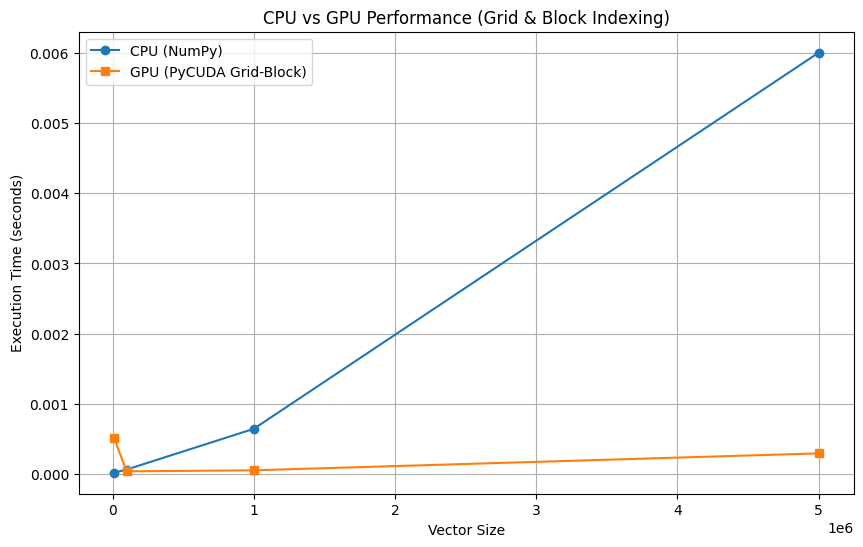

In [8]:
# Execution Time Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(sizes, cpu_times, marker='o', label='CPU (NumPy)')
plt.plot(sizes, gpu_times, marker='s', label='GPU (PyCUDA Grid-Block)')

plt.xlabel("Vector Size")
plt.ylabel("Execution Time (seconds)")
plt.title("CPU vs GPU Performance (Grid & Block Indexing)")
plt.legend()
plt.grid(True)

plt.show()

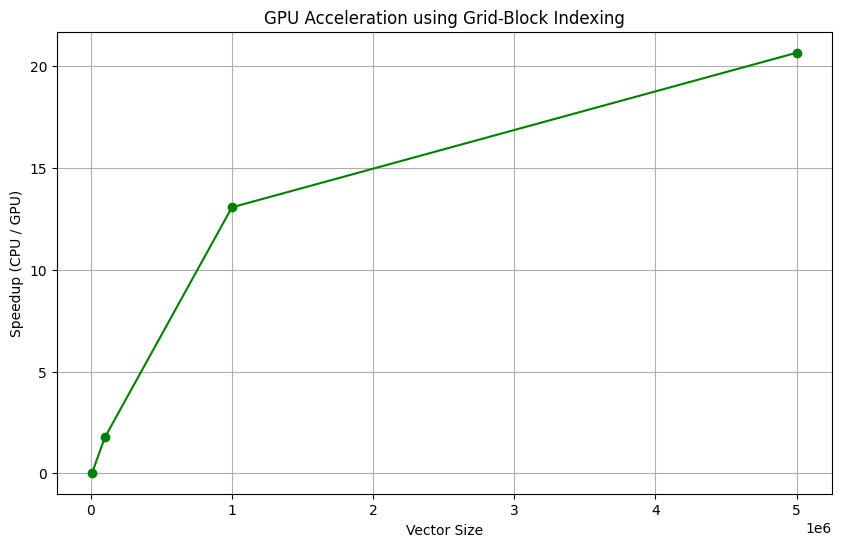

In [9]:
# Speedup Visualization
speedup = [c/g for c, g in zip(cpu_times, gpu_times)]

plt.figure(figsize=(10,6))

plt.plot(sizes, speedup, marker='o', color='green')

plt.xlabel("Vector Size")
plt.ylabel("Speedup (CPU / GPU)")
plt.title("GPU Acceleration using Grid-Block Indexing")
plt.grid(True)

plt.show()